In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import os

import warnings
warnings.filterwarnings("ignore")

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows',15)

Accuracy will be misleading.

Example:
If a model predicts everyone as TARGET = 0,
accuracy itself will be around 91.88%.

But that model is useless because it fails to identify risky customers.

So we have to focus more on :
ROC-AUC
Recall for TARGET = 1
Precision for TARGET = 1
F1-score
KS Statistic
Decile analysis

In [4]:
df = pd.read_csv(r"E:\\home-credit-risk\\data\\application_train.csv")

In [5]:
missing_df = df.isnull().sum().reset_index()
missing_df.columns = ['column_name', 'missing_count']

missing_df['missing_percentage'] = (missing_df['missing_count'] / len(df)) * 100
missing_df.sort_values(by='missing_percentage', ascending=False, inplace=True)

In [6]:
cat_columns = df.select_dtypes(include=['object']).columns.tolist()
num_columns = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"Number of categorical columns: {len(cat_columns)}")
print(f"Number of numerical columns: {len(num_columns)}")

Number of categorical columns: 17
Number of numerical columns: 105


### Better Missing Value Summary

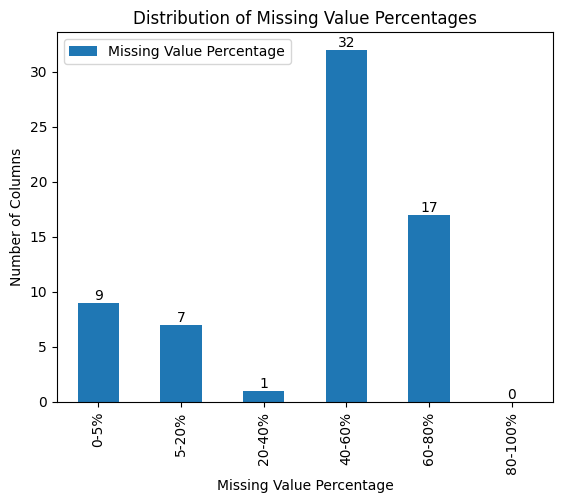

In [13]:
missing_df["missing_bucket"] = pd.cut(
    missing_df["missing_percentage"],
    bins=[0, 5, 20, 40, 60, 80, 100],
    labels=["0-5%", "5-20%", "20-40%", "40-60%", "60-80%", "80-100%"]
)

ax = missing_df["missing_bucket"].value_counts().sort_index().plot(
    kind="bar",
    label="Missing Value Percentage"
)

plt.title("Distribution of Missing Value Percentages")
plt.xlabel("Missing Value Percentage")
plt.ylabel("Number of Columns") 
plt.legend()

# annotate bar values
ax.bar_label(ax.containers[0])

plt.show()

In [20]:
from IPython.display import display, HTML

desc_df = df[num_columns].describe().T

display(HTML(
    desc_df.to_html()
    .replace(
        '<table border="1" class="dataframe">',
        '<div style="max-height:400px; overflow-y:auto;"><table border="1" class="dataframe">'
    )
    + '</div>'
))

,count,mean,std,min,25%,50%,75%,max
TARGET,199882.0,0.081203,0.273147,0.000000e+00,0.000000,0.000000,0.000000,1.000000e+00
CNT_CHILDREN,199882.0,0.419447,0.726197,0.000000e+00,0.000000,0.000000,1.000000,1.900000e+01
AMT_INCOME_TOTAL,199882.0,168632.853089,106641.438946,2.565000e+04,112500.000000,148500.000000,202500.000000,1.350000e+07
AMT_CREDIT,199882.0,599712.703893,402591.407437,4.500000e+04,270000.000000,517266.000000,808650.000000,4.050000e+06
AMT_ANNUITY,199872.0,27143.727080,14585.657047,1.615500e+03,16524.000000,24912.000000,34654.500000,2.580255e+05
AMT_GOODS_PRICE,199697.0,539169.640653,369670.566339,4.050000e+04,238500.000000,450000.000000,679500.000000,4.050000e+06
REGION_POPULATION_RELATIVE,199882.0,0.020896,0.013859,2.900000e-04,0.010006,0.018850,0.028663,7.250800e-02
DAYS_BIRTH,199882.0,-16026.845549,4363.761714,-2.522900e+04,-19670.000000,-15738.000000,-12396.000000,-7.673000e+03
DAYS_EMPLOYED,199882.0,63590.955214,141083.570901,-1.791200e+04,-2761.000000,-1215.000000,-290.000000,3.652430e+05
DAYS_REGISTRATION,199882.0,-4985.351703,3517.832569,-2.467200e+04,-7468.000000,-4507.000000,-2016.000000,0.000000e+00


In [24]:
df[num_columns]

,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,TOTALAREA_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,0,0,360000.0,1125000.0,33025.5,1125000.0,0.022800,-18943,-7369,-2353.0,-2479,NaN,1,1,0,1,0,0,2.0,2,2,11,0,0,0,0,1,1,NaN,0.358116,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,0,0,112500.0,251280.0,13630.5,180000.0,0.022625,-13894,-1393,-5698.0,-5698,NaN,1,1,0,1,0,0,2.0,2,2,14,0,0,0,0,0,0,NaN,0.414341,0.792264,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,-1645.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,6.0
2,0,0,225000.0,544491.0,15916.5,454500.0,0.035792,-19821,-2075,-2121.0,-3379,NaN,1,1,1,1,0,0,2.0,2,2,16,0,0,0,0,0,0,NaN,0.438705,0.189595,0.0773,0.0888,0.9776,0.6940,0.0634,0.00,0.1724,0.1667,0.0000,0.0476,0.0630,0.0468,0.0077,0.0098,0.0788,0.0922,0.9777,0.7060,0.0640,0.0000,0.1724,0.1667,0.0000,0.0487,0.0689,0.0487,0.0078,0.0103,0.0781,0.0888,0.9776,0.6981,0.0638,0.00,0.1724,0.1667,0.0000,0.0484,0.0641,0.0476,0.0078,0.0100,0.0563,0.0,0.0,0.0,0.0,-1062.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,1.0,0.0,0.0,2.0
3,0,2,211500.0,900000.0,26316.0,900000.0,0.006207,-13034,-2205,-1193.0,-4141,NaN,1,1,1,1,0,0,4.0,2,2,17,0,0,0,0,0,0,NaN,0.717402,0.272134,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,-484.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
4,1,0,90000.0,113760.0,8406.0,90000.0,0.020713,-18393,-1694,-8279.0,-1890,NaN,1,1,1,1,0,0,2.0,3,3,12,0,0,0,0,0,0,NaN,0.062386,0.436506,0.3918,0.3193,0.9911,0.8776,0.0940,0.56,0.4828,0.3333,0.3750,0.3421,0.3194,0.4972,0.0232,0.0350,0.3992,0.3313,0.9911,0.8824,0.0949,0.5639,0.4828,0.3333,0.3750,0.3499,0.3489,0.5180,0.0233,0.0370,0.3955,0.3193,0.9911,0.8792,0.0946,0.56,0.4828,0.3333,0

### Feature Engineering Age / Employed Years / Registration Years / ID Publish Years

In [25]:
df["AGE_YEARS"] = -df["DAYS_BIRTH"] // 365
df["EMPLOYED_YEARS"] = -df["DAYS_EMPLOYED"] // 365
df["REGISTRATION_YEARS"] = -df["DAYS_REGISTRATION"] // 365
df["ID_PUBLISH_YEARS"] = -df["DAYS_ID_PUBLISH"] // 365

In [26]:
df[["AGE_YEARS", "EMPLOYED_YEARS", "REGISTRATION_YEARS", "ID_PUBLISH_YEARS"]].describe().T

,count,mean,std,min,25%,50%,75%,max
AGE_YEARS,199882.0,43.408376,11.953884,21.0,33.0,43.0,53.0,69.0
EMPLOYED_YEARS,199882.0,-174.687891,386.468803,-1001.0,0.0,3.0,7.0,49.0
REGISTRATION_YEARS,199882.0,13.166778,9.633430,0.0,5.0,12.0,20.0,67.0
ID_PUBLISH_YEARS,199882.0,7.709399,4.129397,0.0,4.0,8.0,11.0,19.0


In [27]:
df['DAYS_EMPLOYED'].value_counts().head(10)

DAYS_EMPLOYED
 365243    35869
-199         108
-229         108
-200         108
-212         106
-224         105
-230          96
-233          92
-216          92
-231          92
Name: count, dtype: int64

In [30]:
(df['DAYS_EMPLOYED'] == 365243).mean() * 100

np.float64(17.945087601684996)

### Basic Default Rate by Categorical Variables

In [41]:
df.groupby("CODE_GENDER")["TARGET"].agg(
    count = "count", 
    mean_rate_percentage = lambda x: x.mean() * 100).sort_values("mean_rate_percentage", ascending=False)

,count,mean_rate_percentage
CODE_GENDER,,
M,68252,10.122780
F,131626,7.082187
XNA,4,0.000000


In [40]:
df.groupby("NAME_EDUCATION_TYPE")["TARGET"].agg(
    count = "count", 
    mean_rate_percentage = lambda x: x.mean() * 100).sort_values("mean_rate_percentage", ascending=False)

,count,mean_rate_percentage
NAME_EDUCATION_TYPE,,
Lower secondary,2536,11.198738
Secondary / secondary special,141745,9.027479
Incomplete higher,6723,8.627101
Higher education,48785,5.265963
Academic degree,93,2.150538


In [39]:
df.groupby("NAME_INCOME_TYPE")["TARGET"].agg(
     count = "count", 
     default_rate_percentage = lambda x: x.mean() * 100).sort_values("default_rate_percentage", ascending=False)

,count,default_rate_percentage
NAME_INCOME_TYPE,,
Maternity leave,3,66.666667
Unemployed,16,37.500000
Working,103313,9.622216
Commercial associate,46614,7.583559
State servant,14057,5.605748
Pensioner,35858,5.463216
Businessman,8,0.000000
Student,13,0.000000


In [42]:
df.groupby("NAME_CONTRACT_TYPE")["TARGET"].agg(
    count = "count", 
    mean_rate_percentage = lambda x: x.mean() * 100).sort_values("mean_rate_percentage", ascending=False)

,count,mean_rate_percentage
NAME_CONTRACT_TYPE,,
Cash loans,180854,8.402358
Revolving loans,19028,5.439353


CREDIT_INCOME_RATIO:
How large the loan is compared to income.

ANNUITY_INCOME_RATIO:
How much repayment burden exists compared to income.

GOODS_CREDIT_RATIO:
Whether credit amount is close to actual goods price.

EMPLOYED_AGE_RATIO:
How much of the person's life has been spent employed.

In [43]:
df["CREDIT_INCOME_RATIO"] = df["AMT_CREDIT"] / df["AMT_INCOME_TOTAL"]
df["ANNUITY_INCOME_RATIO"] = df["AMT_ANNUITY"] / df["AMT_INCOME_TOTAL"]
df["GOODS_CREDIT_RATIO"] = df["AMT_GOODS_PRICE"] / df["AMT_CREDIT"]
df["EMPLOYED_AGE_RATIO"] = df["EMPLOYED_YEARS"] / df["AGE_YEARS"]

In [44]:
doc_cols = [f"FLAG_DOCUMENT_{i}" for i in range(2, 14)]

df["TOTAL_DOCUMENTS_SUBMITTED"] = df[doc_cols].sum(axis=1)

In [45]:
df['TOTAL_DOCUMENTS_SUBMITTED'].describe()

count    199882.000000
mean          0.906165
std           0.303735
min           0.000000
25%           1.000000
50%           1.000000
75%           1.000000
max           2.000000
Name: TOTAL_DOCUMENTS_SUBMITTED, dtype: float64

In [49]:
df[doc_cols].sum(axis=1)

0         1
1         1
2         1
3         1
4         1
         ..
199877    1
199878    1
199879    0
199880    1
199881    1
Length: 199882, dtype: int64

In [50]:
df.groupby("TOTAL_DOCUMENTS_SUBMITTED")["TARGET"].agg(
    count="count",
    default_rate_percentage=lambda x: x.mean() * 100
)

,count,default_rate_percentage
TOTAL_DOCUMENTS_SUBMITTED,,
0,19478,5.416367
1,179682,8.432119
2,722,3.462604


In [51]:
df["TOTAL_DOCUMENTS_SUBMITTED"].value_counts(normalize=True) * 100

TOTAL_DOCUMENTS_SUBMITTED
1    89.894037
0     9.744749
2     0.361213
Name: proportion, dtype: float64

In [53]:
df["HAS_ANY_DOCUMENT"] = (df["TOTAL_DOCUMENTS_SUBMITTED"] > 0).astype(int)

df.groupby("HAS_ANY_DOCUMENT")["TARGET"].agg(
    count="count",
    default_rate_percentage=lambda x: x.mean() * 100
)

,count,default_rate_percentage
HAS_ANY_DOCUMENT,,
0,19478,5.416367
1,180404,8.412230


In [54]:
df.to_csv(r"E:\\home-credit-risk\\data\\EDA_102_Completed.csv", index=False)